In [21]:
import torch
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import StanfordCars
from torchvision.models import resnet50, efficientnet_b0
from torch.utils.data import DataLoader, random_split
import torch.nn as nn
import numpy as np
from sklearn.neighbors import NearestNeighbors
from tqdm import tqdm
import matplotlib.pyplot as plt
from PIL import Image
import random
import umap

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [59]:
# Play with values
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.4, scale=(0.02, 0.2), ratio=(0.3, 3.3), value=0)  # Add cutout
])

train_dataset = StanfordCars(root='./', split='train', download=False, transform=transform)
test_dataset = StanfordCars(root='./', split='test', download=False, transform=transform)

In [60]:
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

print(f"Train size: {train_size}, Validation size: {val_size}")

Train size: 6515, Validation size: 1629


In [61]:
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [62]:
NUM_CLASSES = 196

# Load pretrained EfficientNet
model = efficientnet_b0(weights="IMAGENET1K_V1")


# Replace classifier head for Cars196
model.classifier[0] = torch.nn.Dropout(p=0.4)  # Increase dropout rate
model.classifier[1] = torch.nn.Linear(model.classifier[1].in_features, NUM_CLASSES)
model = model.to(device)

# Loss and Optimizer
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=8e-5, weight_decay=2e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=3, factor=0.5)


100%|██████████| 204/204 [00:57<00:00,  3.58it/s]



Epoch [1/15]
🟢 Train Loss: 5.2454 | Train Acc: 0.0144 | Train Precision: 0.0149
🔵 Val Loss:   5.0982 | Val Acc:   0.0460 | Val Precision:   0.0476
✅ Model saved (best validation loss)


100%|██████████| 204/204 [00:57<00:00,  3.57it/s]



Epoch [2/15]
🟢 Train Loss: 4.8689 | Train Acc: 0.0712 | Train Precision: 0.0802
🔵 Val Loss:   4.5351 | Val Acc:   0.1185 | Val Precision:   0.1297
✅ Model saved (best validation loss)


100%|██████████| 204/204 [00:54<00:00,  3.77it/s]


...


Epoch [13/15]
🟢 Train Loss: 0.7786 | Train Acc: 0.8447 | Train Precision: 0.8463
🔵 Val Loss:   1.0665 | Val Acc:   0.7176 | Val Precision:   0.7479
✅ Model saved (best validation loss)


100%|██████████| 204/204 [00:54<00:00,  3.77it/s]



Epoch [14/15]
🟢 Train Loss: 0.7014 | Train Acc: 0.8502 | Train Precision: 0.8517
🔵 Val Loss:   1.0181 | Val Acc:   0.7336 | Val Precision:   0.7606
✅ Model saved (best validation loss)


100%|██████████| 204/204 [00:54<00:00,  3.76it/s]



Epoch [15/15]
🟢 Train Loss: 0.6031 | Train Acc: 0.8817 | Train Precision: 0.8834
🔵 Val Loss:   0.9689 | Val Acc:   0.7409 | Val Precision:   0.7703
✅ Model saved (best validation loss)

🎉 Training Complete!


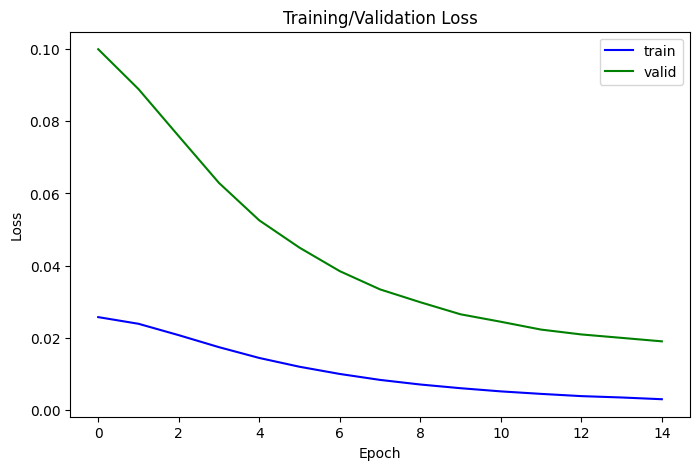

In [63]:
from sklearn.metrics import precision_score

EPOCHS = 15
best_val_loss = float('inf')
patience = 3  # Stop training if validation loss doesn't improve after 5 epochs
patience_counter = 0
train_losses = []
val_losses = []


for epoch in range(EPOCHS):
    # ========== TRAINING ==========
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    train_preds = []
    train_labels = []
    
    for images, labels in tqdm(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        # Accuracy calculation
        _, predicted = torch.max(outputs, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

        # Collect predictions and labels for precision calculation
        train_preds.extend(predicted.cpu().numpy())
        train_labels.extend(labels.cpu().numpy())

    # Compute train loss, accuracy, and precision
    train_loss /= len(train_loader)
    train_acc = train_correct / train_total
    train_precision = precision_score(train_labels, train_preds, average='weighted', zero_division=0)

    # ========== VALIDATION ==========
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    val_preds = []
    val_labels = []
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            # Accuracy calculation
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

            # Collect predictions and labels for precision calculation
            val_preds.extend(predicted.cpu().numpy())
            val_labels.extend(labels.cpu().numpy())

    # Compute validation loss, accuracy, and precision
    val_loss /= len(val_loader)
    val_acc = val_correct / val_total
    val_precision = precision_score(val_labels, val_preds, average='weighted', zero_division=0)

    # ========== OUTPUT ==========
    print(f"\nEpoch [{epoch + 1}/{EPOCHS}]")
    print(f"🟢 Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Train Precision: {train_precision:.4f}")
    print(f"🔵 Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f} | Val Precision:   {val_precision:.4f}")

    # ========== LEARNING RATE SCHEDULING ==========
    scheduler.step(val_loss)

    # ========== EARLY STOPPING ==========
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'efficientnet_cars196_best.pth')
        print("✅ Model saved (best validation loss)")
    else:
        patience_counter += 1
        print(f"⚠️ No improvement in validation loss for {patience_counter}/{patience} epochs.")

    if patience_counter >= patience:
        print(f"\n⏹️ Early stopping triggered after {patience} epochs without improvement.")
        break
    # At the end of each epoch
    train_losses.append(train_loss / len(train_loader))
    val_losses.append(val_loss / len(val_loader))

print("\n🎉 Training Complete!")
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='train', color='blue')
plt.plot(val_losses, label='valid', color='green')
plt.title('Training/Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [64]:
# Load the best model
model.load_state_dict(torch.load('efficientnet_cars196_best.pth'))
model.eval()

# Remove the classifier head to extract embeddings
embedding_model = torch.nn.Sequential(*(list(model.children())[:-1]))
embedding_model = embedding_model.to(device)

C:\Windows\Temp\ipykernel_45720\1877562898.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('efficientnet_cars196_best.pth'))


In [65]:
embeddings = []
file_names = []

with torch.no_grad():
    for images, labels in tqdm(test_loader):
        images = images.to(device)
        embedding = embedding_model(images).squeeze(-1).squeeze(-1)
        embeddings.extend(embedding.cpu().numpy())
        file_names.extend(labels.cpu().numpy())

embeddings = np.array(embeddings)

100%|██████████| 252/252 [01:00<00:00,  4.16it/s]


In [66]:
def retrieve_images(query_idx):
    # Step 1: Get the query embedding
    query_embedding = embeddings[query_idx]

    # Step 2: Compute Euclidean distances manually
    distances = np.linalg.norm(embeddings - query_embedding, axis=1)

    # Step 3: Sort by distance and exclude the query itself
    sorted_indices = np.argsort(distances)
    retrieved_indices = [idx for idx in sorted_indices if idx != query_idx][:5]
    retrieved_distances = [distances[idx] for idx in retrieved_indices]

    # Step 4: Create a plot to display results
    fig, axs = plt.subplots(1, len(retrieved_indices) + 1, figsize=(20, 5))
    
    # Query image
    query_img, _ = test_dataset[query_idx]
    axs[0].imshow(query_img.permute(1, 2, 0))
    axs[0].set_title("Query")
    axs[0].axis("off")

    # Retrieved images with distances
    for i, (idx, dist) in enumerate(zip(retrieved_indices, retrieved_distances)):
        retrieved_img, _ = test_dataset[idx]
        axs[i + 1].imshow(retrieved_img.permute(1, 2, 0))
        axs[i + 1].set_title(f"Dist: {dist:.3f}")
        axs[i + 1].axis("off")

    plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.4025275].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.9951199].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.622571].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.9428324].


🔎 Retrieval 1:


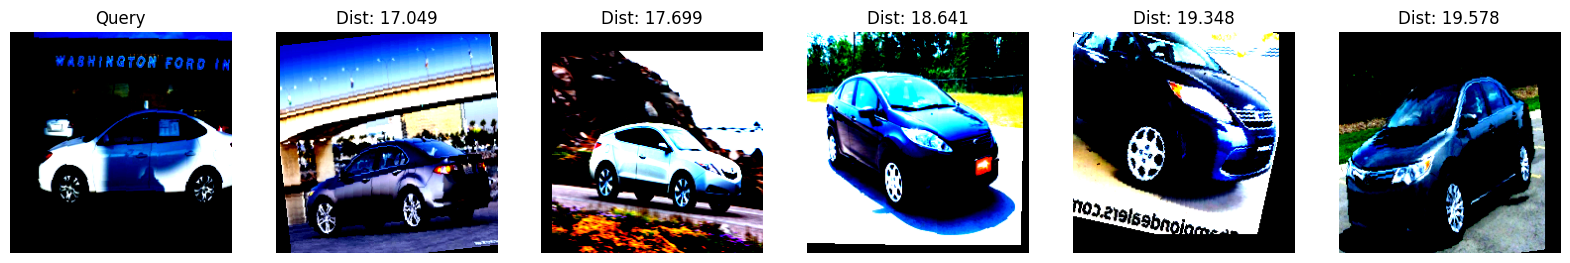

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.367669].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.2914162].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.4134207].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.2979523].


🔎 Retrieval 2:


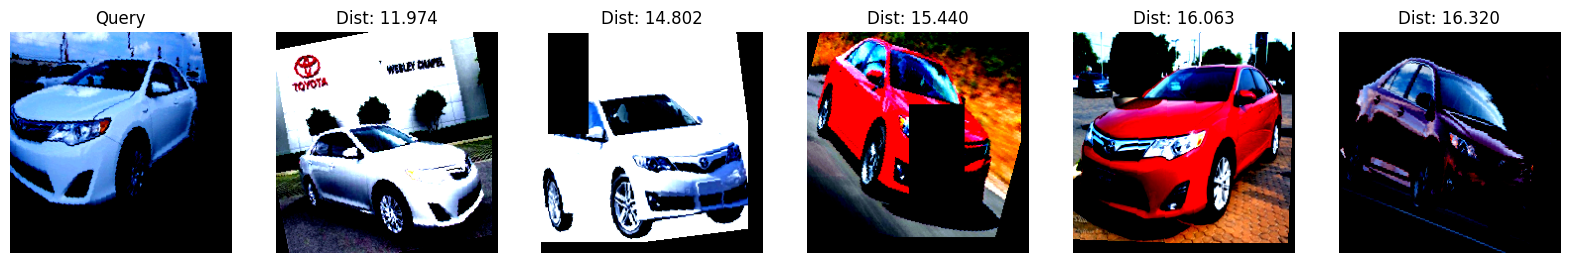

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.2282355].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.2805231].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.186841].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.1585187].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.4896734].


🔎 Retrieval 3:


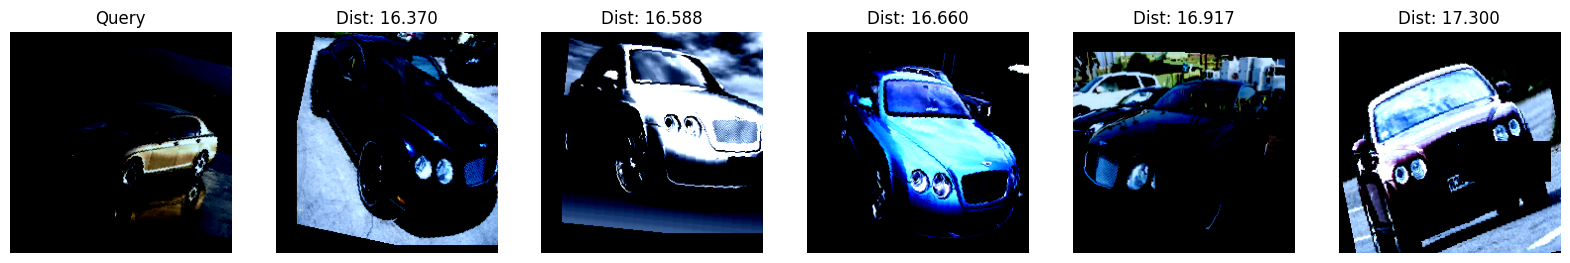

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.186841].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.2216995].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


🔎 Retrieval 4:


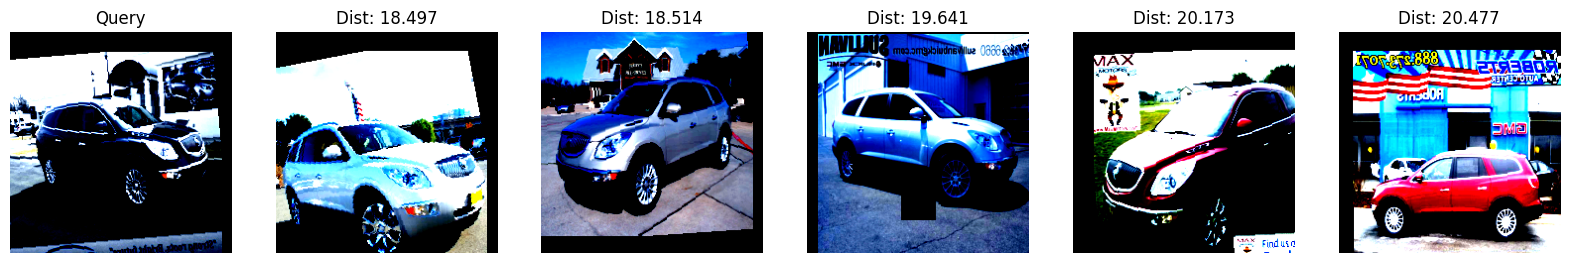

🔎 Retrieval 5:


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.0299783].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.8905448].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


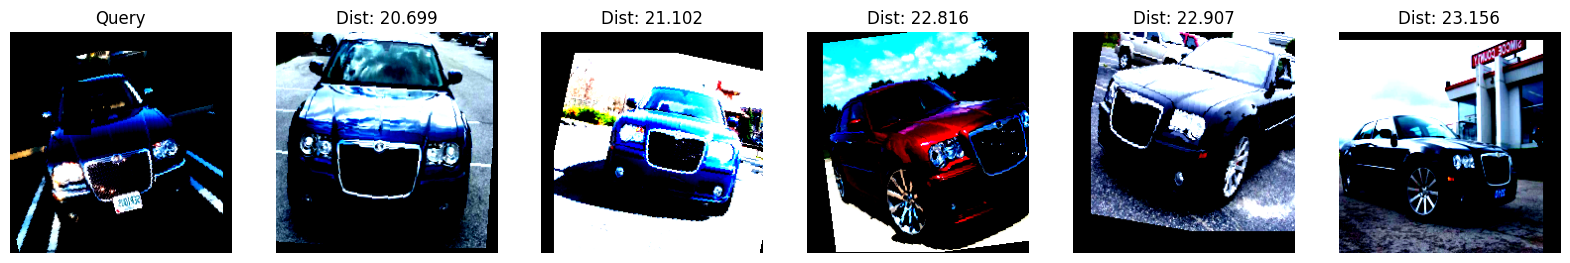

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.9776908].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.8033988].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.907974].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


🔎 Retrieval 6:


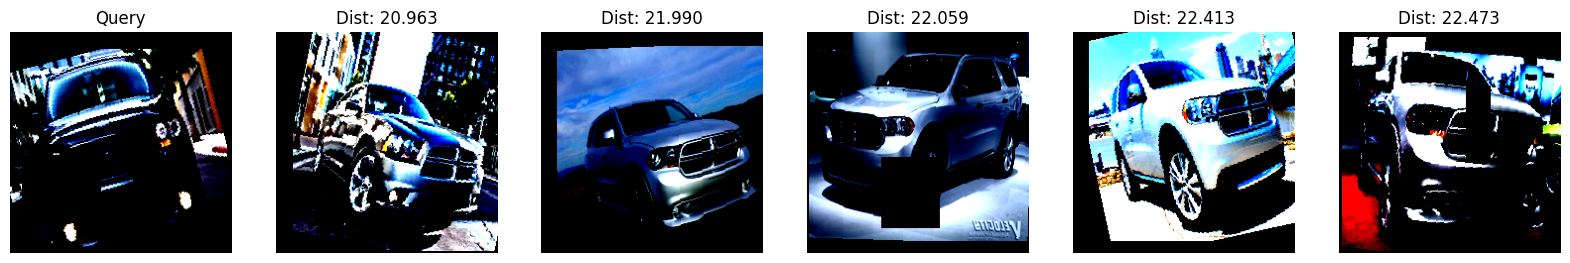

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.8382572].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.6813945].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.8382572].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.0190852].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.4722441].


🔎 Retrieval 7:


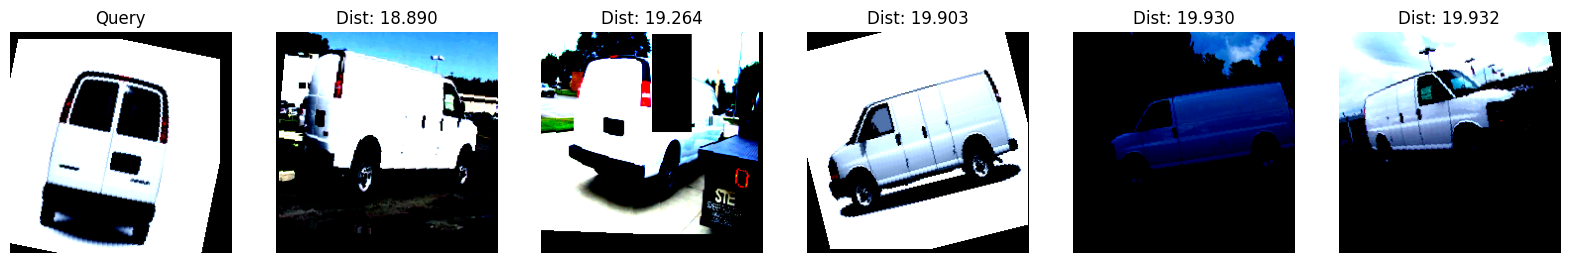

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.5071026].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.2805231].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.3088455].


🔎 Retrieval 8:


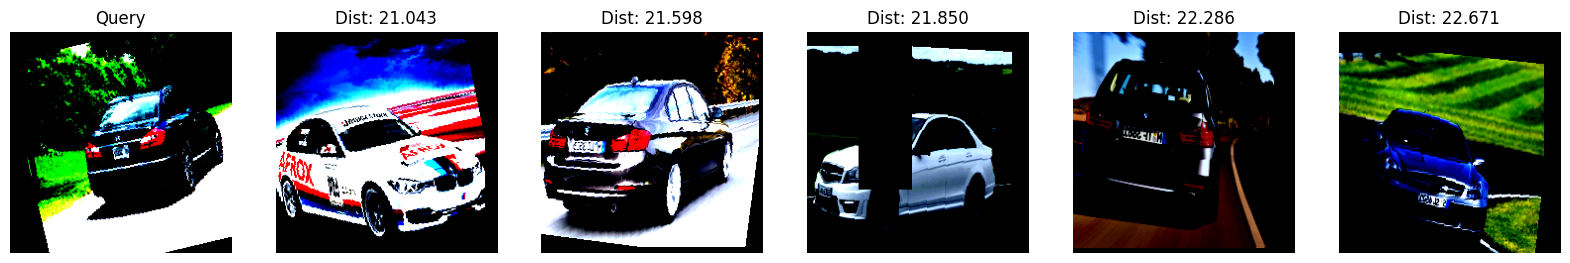

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.2282355].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.4722441].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.5768193].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.193377].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


🔎 Retrieval 9:


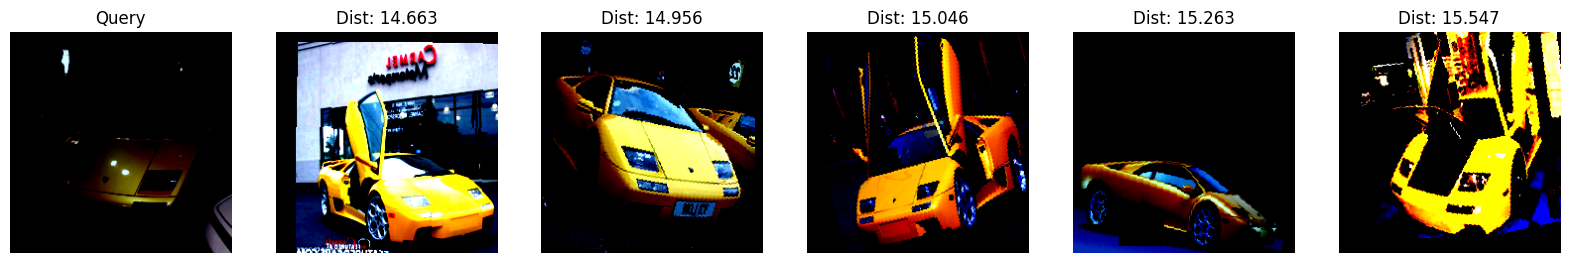

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.186841].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.3959913].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.2556022].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


🔎 Retrieval 10:


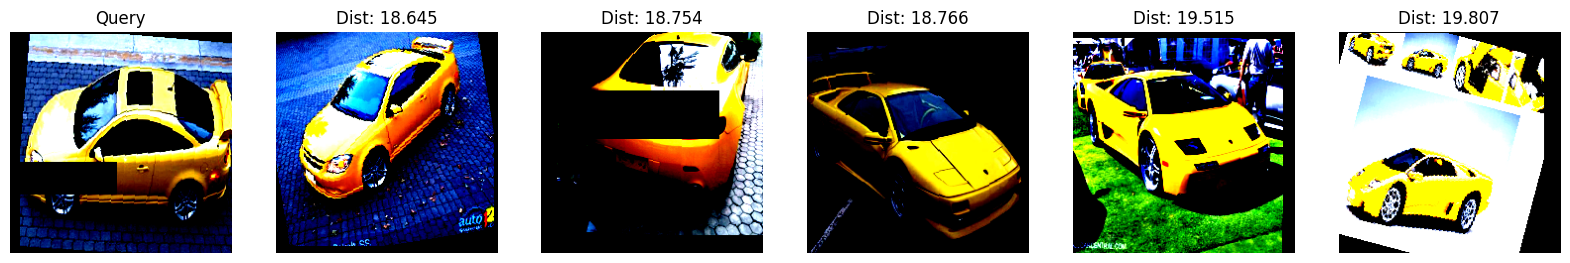

In [67]:
import random

def retrieve_random_cars(num_samples=10):
    random_indices = random.sample(range(len(test_dataset)), num_samples)
    
    for i, idx in enumerate(random_indices):
        print(f"🔎 Retrieval {i + 1}:")
        retrieve_images(idx)  # Call the existing retrieval function

# Run the loop
retrieve_random_cars(10)


✅ Mosaic saved to clustering_mosaic.png


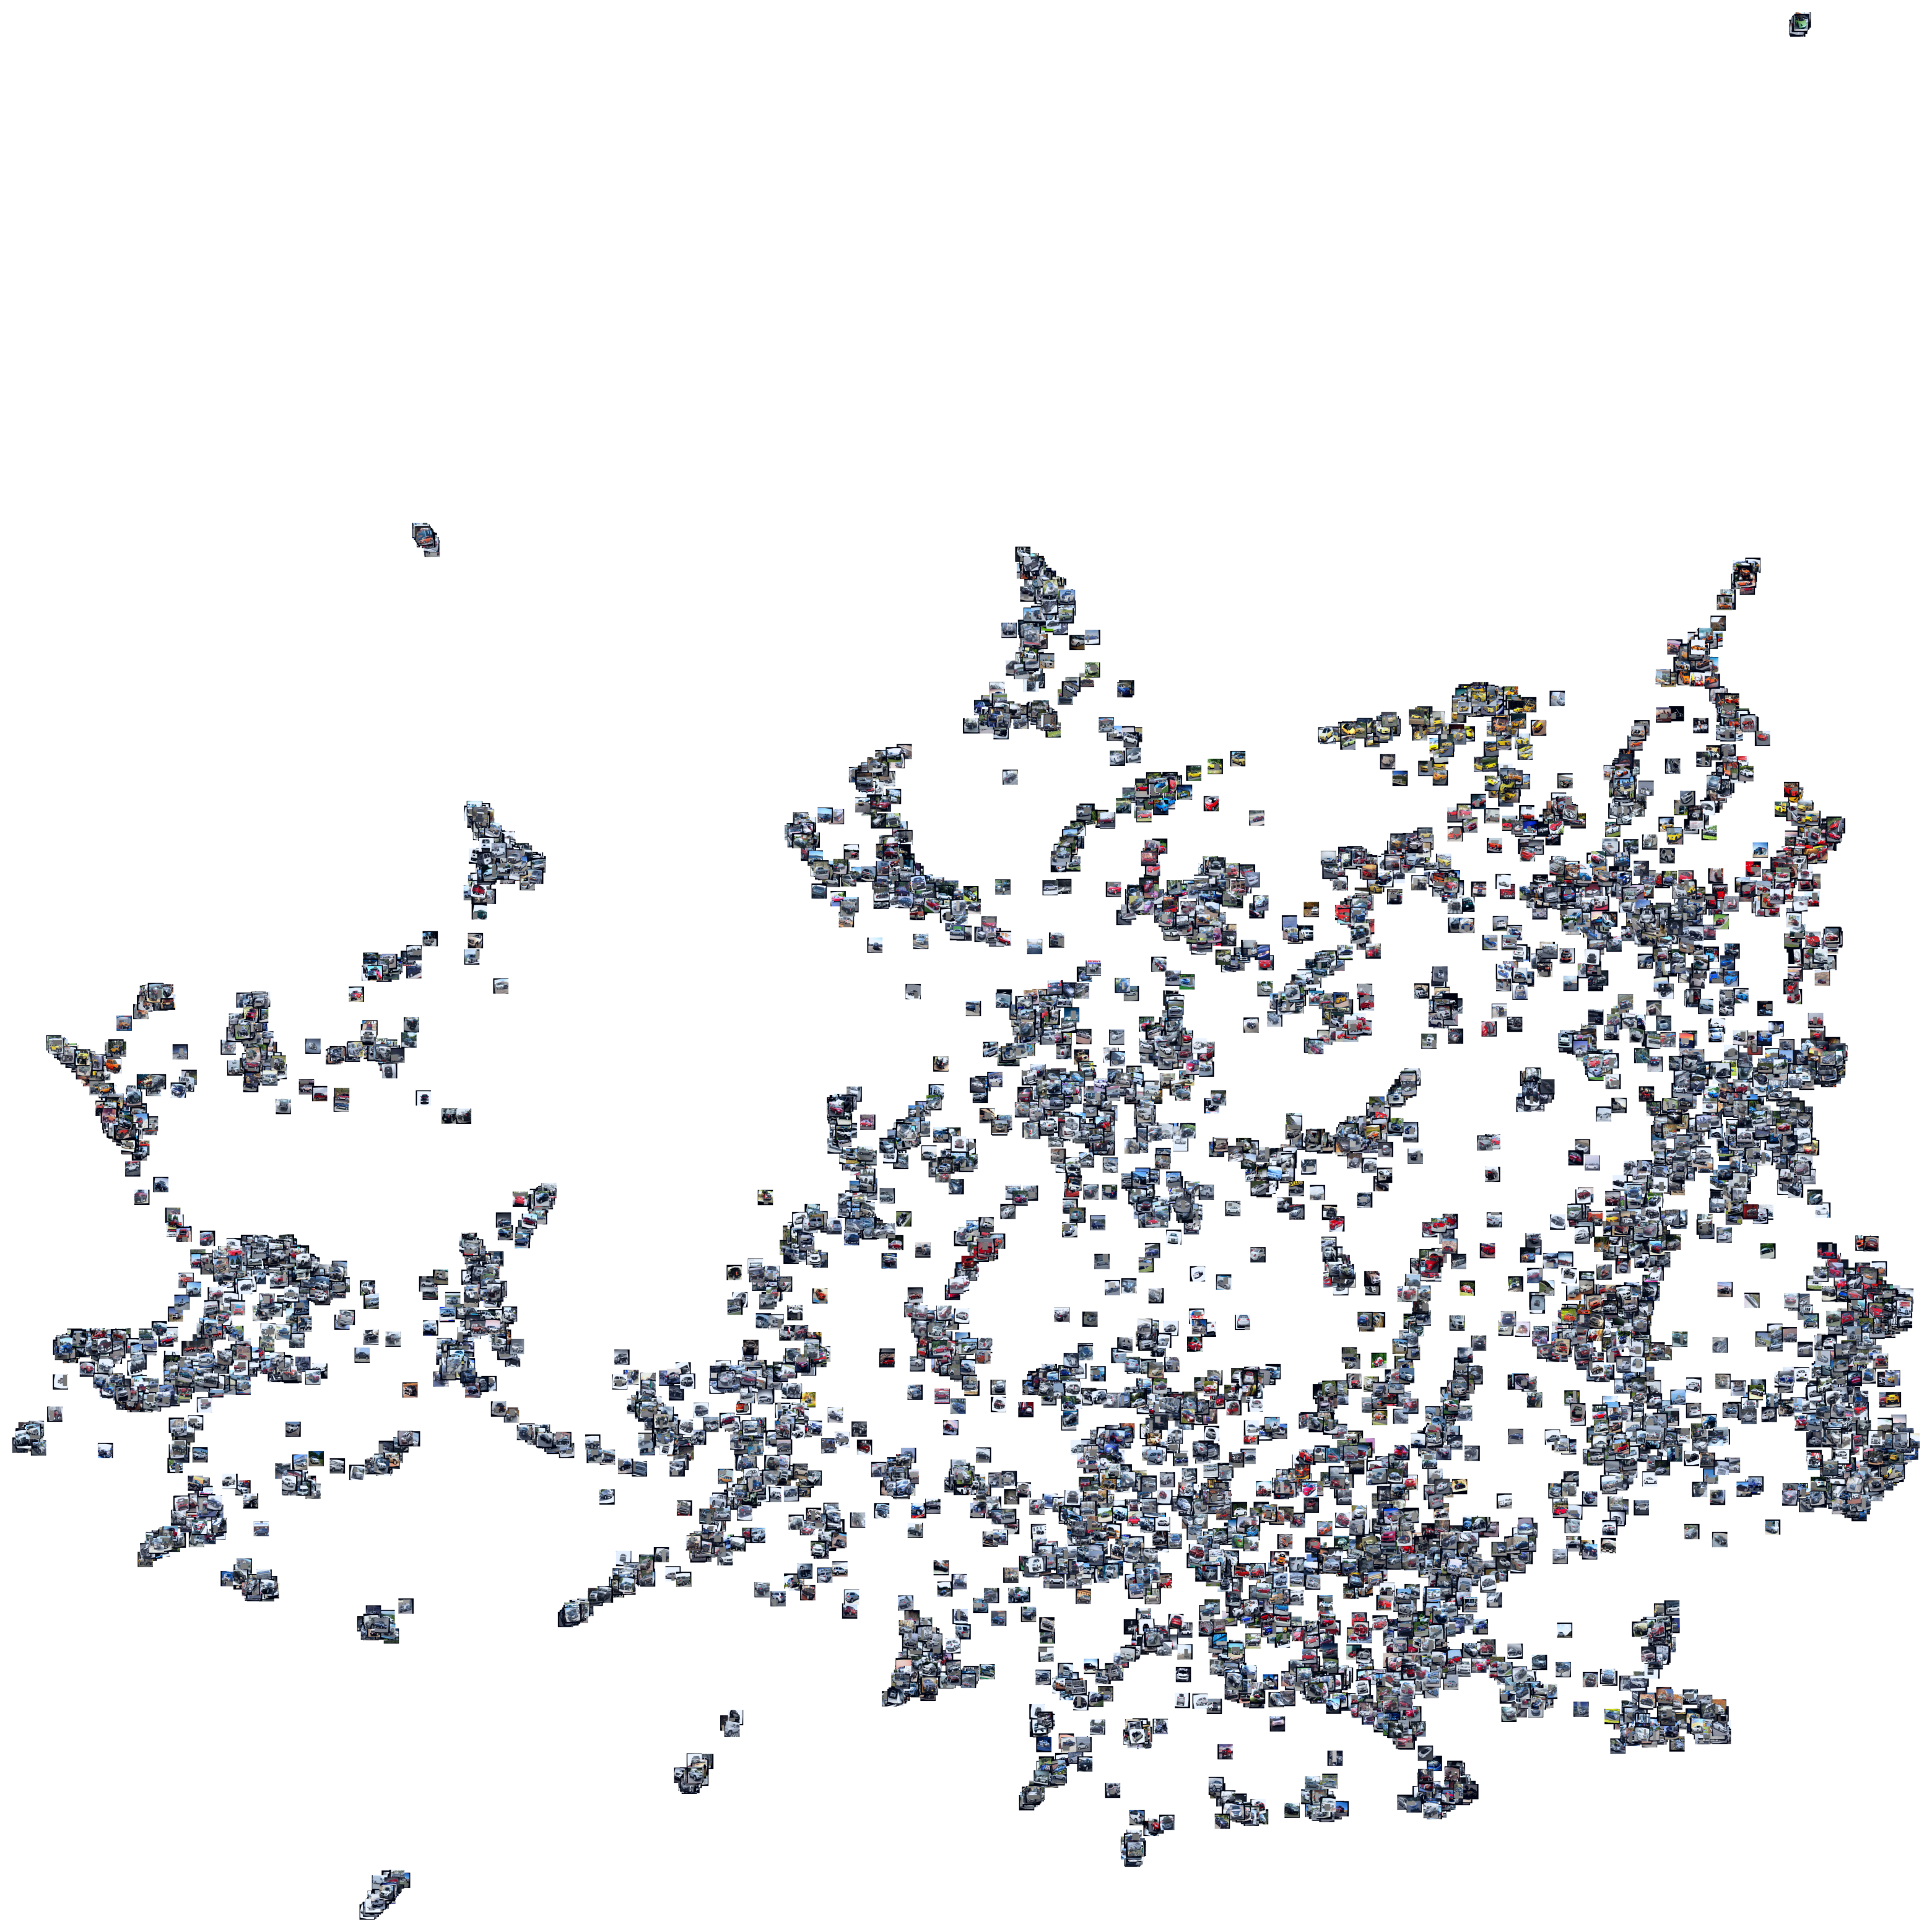

In [68]:

# Step 1: Reduce embeddings using UMAP
reduced_embeddings = umap.UMAP(n_components=2, n_neighbors=30).fit_transform(embeddings)

# Normalize coordinates to [0, 1] for consistent scaling
min_x, max_x = reduced_embeddings[:, 0].min(), reduced_embeddings[:, 0].max()
min_y, max_y = reduced_embeddings[:, 1].min(), reduced_embeddings[:, 1].max()

reduced_embeddings[:, 0] = (reduced_embeddings[:, 0] - min_x) / (max_x - min_x)
reduced_embeddings[:, 1] = (reduced_embeddings[:, 1] - min_y) / (max_y - min_y)

# Step 2: Define larger canvas size for better detail
canvas_size = 10000   # Larger size for higher resolution
img_size = 80         # Larger image size for better zoom quality

# Create a blank white canvas
canvas = Image.new('RGB', (canvas_size, canvas_size), (255, 255, 255))

# Step 3: Paste images into the canvas
for i, (x, y) in enumerate(reduced_embeddings):
    # Load image from dataset
    img, _ = test_dataset[i]
    img = img.permute(1, 2, 0).numpy()
    img = (img - img.min()) / (img.max() - img.min())  # Normalize to [0, 1]
    img = Image.fromarray((img * 255).astype(np.uint8)).resize((img_size, img_size))

    # Compute position on canvas
    pos_x = int(x * (canvas_size - img_size))
    pos_y = int(y * (canvas_size - img_size))

    # Paste onto the canvas
    canvas.paste(img, (pos_x, pos_y))

# Step 4: Save the canvas with high DPI for better quality
output_path = 'clustering_mosaic.png'
canvas.save(output_path, dpi=(300, 300))   # Save with high DPI
print(f"✅ Mosaic saved to {output_path}")

# Step 5: Display the result at high resolution
plt.figure(figsize=(20, 20), dpi=200)  # Larger figure size and higher DPI
plt.imshow(canvas)
plt.axis('off')
plt.show()
